### Modelo Corrido Kaggle GPU T4 x2

# Biliary Specialist + Ensemble Conservador 

In [1]:
!pip -q install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 32.6 MB/s eta 0:00:0000:0100:01


In [ ]:
from pathlib import Path
import copy
import time
import random
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision.models import efficientnet_b7

from monai.transforms import (
    Compose,
    LoadImage,
    EnsureChannelFirst,
    Resize,
    NormalizeIntensity,
    Lambda,
    ToTensor
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

CLASS_NAMES = ["Biliary_Leaks", "Lithiasis", "Normal", "Stricture"]
NUM_CLASSES = len(CLASS_NAMES)

POSITIVE_CLASS = "Biliary_Leaks"
POSITIVE_IDX = CLASS_NAMES.index(POSITIVE_CLASS)

REAL_DATASET_ROOT = Path("/kaggle/input/datasets/martimflix/dataset_monica/dataset_monica")
GENERATED_ROOT = Path("/kaggle/input/datasets/martimflix/vae-generated/vae_generated_perceptual")

REAL_TRAIN_DIR = REAL_DATASET_ROOT / "train"
VAL_DIR = REAL_DATASET_ROOT / "val"
TEST_DIR = REAL_DATASET_ROOT / "test"

EFFICIENTNET_CKPT_PATH = Path(
    "/kaggle/input/models/martimflix/efficientnet/pytorch/default/1/efficientnet_b7.pth"
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-05-31 10:58:25.708665: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780225105.914255      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780225105.973619      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780225106.479029      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780225106.479099      57 computation_placer.cc:1

Device: cuda


In [3]:
def count_images(folder):
    exts = ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"]
    files = []

    if not folder.exists():
        return 0

    for ext in exts:
        files.extend(folder.glob(ext))

    return len(files)


rows = []

for cls in CLASS_NAMES:
    rows.append({
        "Class": cls,
        "Real train": count_images(REAL_TRAIN_DIR / cls),
        "Generated": count_images(GENERATED_ROOT / cls),
        "Val real": count_images(VAL_DIR / cls),
        "Test real": count_images(TEST_DIR / cls)
    })

counts_df = pd.DataFrame(rows)
counts_df

,Class,Real train,Generated,Val real,Test real
0,Biliary_Leaks,110,300,24,17
1,Lithiasis,505,0,98,123
2,Normal,197,300,59,43
3,Stricture,255,300,53,84


In [4]:
def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img


train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

eval_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

print("Transforms ready.")

Transforms ready.


In [5]:
USE_GENERATED_BILIARY = True


def collect_binary_paths(root_dir):
    image_files = []
    labels = []

    for cls in CLASS_NAMES:
        cls_dir = root_dir / cls

        cls_files = []
        for ext in ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"]:
            cls_files.extend(cls_dir.glob(ext))

        cls_files = sorted(cls_files)

        binary_label = 1 if cls == POSITIVE_CLASS else 0

        image_files.extend(cls_files)
        labels.extend([binary_label] * len(cls_files))

    return image_files, labels


def collect_binary_train_paths(real_train_dir, generated_root, use_generated_biliary=False):
    image_files, labels = collect_binary_paths(real_train_dir)

    if use_generated_biliary:
        gen_dir = generated_root / POSITIVE_CLASS

        generated_files = []
        for ext in ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"]:
            generated_files.extend(gen_dir.glob(ext))

        generated_files = sorted(generated_files)

        image_files.extend(generated_files)
        labels.extend([1] * len(generated_files))

    return image_files, labels


class BinaryPathDataset(Dataset):
    def __init__(self, image_files, labels, transform):
        self.image_files = list(image_files)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img = self.transform(str(self.image_files[idx]))
        label = torch.tensor(float(self.labels[idx]), dtype=torch.float32)
        return img, label


binary_train_files, binary_train_labels = collect_binary_train_paths(
    real_train_dir=REAL_TRAIN_DIR,
    generated_root=GENERATED_ROOT,
    use_generated_biliary=USE_GENERATED_BILIARY
)

binary_val_files, binary_val_labels = collect_binary_paths(VAL_DIR)
binary_test_files, binary_test_labels = collect_binary_paths(TEST_DIR)

binary_train_ds = BinaryPathDataset(
    binary_train_files,
    binary_train_labels,
    train_transforms
)

binary_val_ds = BinaryPathDataset(
    binary_val_files,
    binary_val_labels,
    eval_transforms
)

binary_test_ds = BinaryPathDataset(
    binary_test_files,
    binary_test_labels,
    eval_transforms
)

binary_counts_df = pd.DataFrame([
    {
        "Split": "Train",
        "Biliary_Leaks": int(sum(binary_train_labels)),
        "Rest": int(len(binary_train_labels) - sum(binary_train_labels)),
        "Total": len(binary_train_labels)
    },
    {
        "Split": "Validation",
        "Biliary_Leaks": int(sum(binary_val_labels)),
        "Rest": int(len(binary_val_labels) - sum(binary_val_labels)),
        "Total": len(binary_val_labels)
    },
    {
        "Split": "Test",
        "Biliary_Leaks": int(sum(binary_test_labels)),
        "Rest": int(len(binary_test_labels) - sum(binary_test_labels)),
        "Total": len(binary_test_labels)
    }
])

binary_counts_df

,Split,Biliary_Leaks,Rest,Total
0,Train,410,957,1367
1,Validation,24,210,234
2,Test,17,250,267


In [6]:
BATCH_SIZE = 8

binary_train_loader = DataLoader(
    binary_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

binary_val_loader = DataLoader(
    binary_val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

binary_test_loader = DataLoader(
    binary_test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

print("Binary loaders ready.")
print("Train batches:", len(binary_train_loader))
print("Val batches:", len(binary_val_loader))
print("Test batches:", len(binary_test_loader))

Binary loaders ready.
Train batches: 171
Val batches: 30
Test batches: 34


In [7]:
def clean_state_dict_keys(state_dict):
    cleaned = {}

    for k, v in state_dict.items():
        new_k = k

        if new_k.startswith("module."):
            new_k = new_k[len("module."):]

        cleaned[new_k] = v

    return cleaned


def safe_torch_load(path):
    try:
        return torch.load(
            path,
            map_location="cpu",
            weights_only=False
        )
    except TypeError:
        return torch.load(
            path,
            map_location="cpu"
        )


def load_checkpoint_safely(model, checkpoint_path):
    checkpoint = safe_torch_load(checkpoint_path)

    if isinstance(checkpoint, dict):
        if "state_dict" in checkpoint:
            state_dict = checkpoint["state_dict"]
        elif "model_state_dict" in checkpoint:
            state_dict = checkpoint["model_state_dict"]
        else:
            state_dict = checkpoint
    else:
        state_dict = checkpoint

    state_dict = clean_state_dict_keys(state_dict)

    missing, unexpected = model.load_state_dict(state_dict, strict=False)

    print("Checkpoint loaded.")
    print("Missing keys:", len(missing))
    print("Unexpected keys:", len(unexpected))

    return model

In [8]:
def create_multiclass_efficientnet_b7():
    model = efficientnet_b7(weights=None)

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        NUM_CLASSES
    )

    model = load_checkpoint_safely(
        model,
        EFFICIENTNET_CKPT_PATH
    )

    model = model.to(device)
    model.eval()

    return model


@torch.no_grad()
def predict_multiclass(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    for images, labels_binary in loader:
        images = images.to(device)

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(labels_binary.detach().cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels_binary = np.concatenate(all_labels).astype(int)

    return all_labels_binary, all_preds


def evaluate_binary_predictions(y_true, y_pred, title):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    print(f"================ {title} ================")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision Biliary_Leaks: {precision:.4f}")
    print(f"Recall Biliary_Leaks: {recall:.4f}")
    print(f"F1 Biliary_Leaks: {f1:.4f}")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Rest", "Biliary_Leaks"],
        digits=4,
        zero_division=0
    ))
    print("Confusion matrix [Rest, Biliary_Leaks]:")
    print(cm)

    return {
        "accuracy": acc,
        "precision_biliary": precision,
        "recall_biliary": recall,
        "f1_biliary": f1,
        "cm": cm
    }


multiclass_baseline_model = create_multiclass_efficientnet_b7()

val_y_binary, val_preds_multiclass = predict_multiclass(
    multiclass_baseline_model,
    binary_val_loader
)

test_y_binary, test_preds_multiclass = predict_multiclass(
    multiclass_baseline_model,
    binary_test_loader
)

val_preds_biliary_baseline = (val_preds_multiclass == POSITIVE_IDX).astype(int)
test_preds_biliary_baseline = (test_preds_multiclass == POSITIVE_IDX).astype(int)

baseline_binary_val_eval = evaluate_binary_predictions(
    val_y_binary,
    val_preds_biliary_baseline,
    title="EfficientNet-B7 multi-class baseline as Biliary detector - Validation"
)

baseline_binary_test_eval = evaluate_binary_predictions(
    test_y_binary,
    test_preds_biliary_baseline,
    title="EfficientNet-B7 multi-class baseline as Biliary detector - Test"
)

del multiclass_baseline_model

if device.type == "cuda":
    torch.cuda.empty_cache()

Checkpoint loaded.
Missing keys: 0
Unexpected keys: 0
================ EfficientNet-B7 multi-class baseline as Biliary detector - Validation ================
Accuracy: 0.8889
Precision Biliary_Leaks: 0.4375
Recall Biliary_Leaks: 0.2917
F1 Biliary_Leaks: 0.3500
               precision    recall  f1-score   support

         Rest     0.9220    0.9571    0.9393       210
Biliary_Leaks     0.4375    0.2917    0.3500        24

     accuracy                         0.8889       234
    macro avg     0.6798    0.6244    0.6446       234
 weighted avg     0.8723    0.8889    0.8788       234

Confusion matrix [Rest, Biliary_Leaks]:
[[201   9]
 [ 17   7]]
================ EfficientNet-B7 multi-class baseline as Biliary detector - Test ================
Accuracy: 0.9551
Precision Biliary_Leaks: 0.6667
Recall Biliary_Leaks: 0.5882
F1 Biliary_Leaks: 0.6250
               precision    recall  f1-score   support

         Rest     0.9722    0.9800    0.9761       250
Biliary_Leaks     0.6667    0.5

In [9]:
def create_binary_efficientnet_b7():
    # Load original 4-class checkpoint first
    model = efficientnet_b7(weights=None)

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        NUM_CLASSES
    )

    model = load_checkpoint_safely(
        model,
        EFFICIENTNET_CKPT_PATH
    )

    # Replace 4-class head with binary head
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, 1)

    model = model.to(device)

    return model


binary_model = create_binary_efficientnet_b7()

# Freeze all parameters
for param in binary_model.parameters():
    param.requires_grad = False

# Train only classifier
for param in binary_model.classifier.parameters():
    param.requires_grad = True

trainable_params = sum(
    p.numel()
    for p in binary_model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in binary_model.parameters()
)

print(f"Trainable params: {trainable_params:,}")
print(f"Total params:     {total_params:,}")
print(f"Trainable ratio:  {100 * trainable_params / total_params:.4f}%")

Checkpoint loaded.
Missing keys: 0
Unexpected keys: 0
Trainable params: 2,561
Total params:     63,789,521
Trainable ratio:  0.0040%


In [10]:
n_pos = int(sum(binary_train_labels))
n_neg = int(len(binary_train_labels) - sum(binary_train_labels))

pos_weight_value = n_neg / n_pos

pos_weight = torch.tensor(
    [pos_weight_value],
    dtype=torch.float32,
    device=device
)

print("Positive samples:", n_pos)
print("Negative samples:", n_neg)
print("pos_weight:", pos_weight_value)

binary_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

binary_optimizer = torch.optim.AdamW(
    binary_model.classifier.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

binary_scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

Positive samples: 410
Negative samples: 957
pos_weight: 2.3341463414634145


/tmp/ipykernel_57/2165279948.py:24: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  binary_scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


In [11]:
def amp_context():
    if device.type == "cuda":
        return torch.cuda.amp.autocast(enabled=True)
    return nullcontext()


def set_binary_training_mode(model):
    # Keep backbone frozen and stable
    model.eval()

    # Train only classifier
    model.classifier.train()


@torch.no_grad()
def predict_binary_probs(model, loader):
    model.eval()

    all_probs = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)

        logits = model(images).squeeze(1)
        probs = torch.sigmoid(logits)

        all_probs.append(probs.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    return all_labels, all_probs


def threshold_search(y_true, probs):
    y_true = np.asarray(y_true).astype(int)

    rows = []

    for threshold in np.arange(0.01, 1.00, 0.01):
        y_pred = (probs >= threshold).astype(int)

        precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
        recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
        f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
        acc = accuracy_score(y_true, y_pred)

        rows.append({
            "threshold": threshold,
            "accuracy": acc,
            "precision_biliary": precision,
            "recall_biliary": recall,
            "f1_biliary": f1
        })

    df = pd.DataFrame(rows)

    best_row = df.sort_values(
        by=["f1_biliary", "recall_biliary"],
        ascending=False
    ).iloc[0]

    return df, best_row


def evaluate_binary_probs(probs, y_true, threshold, title):
    y_true = np.asarray(y_true).astype(int)
    y_pred = (probs >= threshold).astype(int)

    result = evaluate_binary_predictions(
        y_true,
        y_pred,
        title=title
    )

    result["threshold"] = threshold

    return result


@torch.no_grad()
def evaluate_binary_loss(model, loader):
    model.eval()

    total_loss = 0.0
    all_probs = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images).squeeze(1)
        loss = binary_criterion(logits, labels)

        probs = torch.sigmoid(logits)

        total_loss += loss.item() * images.size(0)

        all_probs.append(probs.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    threshold_df, best_row = threshold_search(
        y_true=all_labels,
        probs=all_probs
    )

    return {
        "loss": total_loss / len(loader.dataset),
        "probs": all_probs,
        "y_true": all_labels,
        "best_threshold": float(best_row["threshold"]),
        "best_f1_biliary": float(best_row["f1_biliary"]),
        "best_precision_biliary": float(best_row["precision_biliary"]),
        "best_recall_biliary": float(best_row["recall_biliary"]),
        "threshold_df": threshold_df
    }

In [12]:
BINARY_EPOCHS = 20
BINARY_PATIENCE = 5

BINARY_BEST_MODEL_PATH = "/kaggle/working/efficientnet_b7_biliary_specialist_vae_best.pth"

best_binary_val_f1 = -1.0
best_binary_epoch = -1
best_binary_threshold = 0.5
epochs_without_improvement = 0

binary_history = []

for epoch in range(1, BINARY_EPOCHS + 1):
    start_time = time.time()

    set_binary_training_mode(binary_model)

    train_loss = 0.0

    for images, labels in binary_train_loader:
        images = images.to(device)
        labels = labels.to(device)

        binary_optimizer.zero_grad(set_to_none=True)

        with amp_context():
            logits = binary_model(images).squeeze(1)
            loss = binary_criterion(logits, labels)

        binary_scaler.scale(loss).backward()
        binary_scaler.step(binary_optimizer)
        binary_scaler.update()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(binary_train_loader.dataset)

    val_eval = evaluate_binary_loss(
        binary_model,
        binary_val_loader
    )

    elapsed = time.time() - start_time

    binary_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_eval["loss"],
        "val_best_threshold": val_eval["best_threshold"],
        "val_f1_biliary": val_eval["best_f1_biliary"],
        "val_precision_biliary": val_eval["best_precision_biliary"],
        "val_recall_biliary": val_eval["best_recall_biliary"],
        "time_sec": elapsed
    })

    print(
        f"Epoch {epoch:02d}/{BINARY_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_eval['loss']:.4f} | "
        f"Val F1 Biliary: {val_eval['best_f1_biliary']:.4f} | "
        f"Val Precision: {val_eval['best_precision_biliary']:.4f} | "
        f"Val Recall: {val_eval['best_recall_biliary']:.4f} | "
        f"Best Th: {val_eval['best_threshold']:.2f} | "
        f"Time: {elapsed:.1f}s"
    )

    if val_eval["best_f1_biliary"] > best_binary_val_f1:
        best_binary_val_f1 = val_eval["best_f1_biliary"]
        best_binary_epoch = epoch
        best_binary_threshold = val_eval["best_threshold"]
        epochs_without_improvement = 0

        torch.save(
            copy.deepcopy(binary_model.state_dict()),
            BINARY_BEST_MODEL_PATH
        )

        print("  New best binary specialist saved.")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= BINARY_PATIENCE:
        print(f"Early stopping at epoch {epoch}. Best epoch: {best_binary_epoch}")
        break


binary_history_df = pd.DataFrame(binary_history)
binary_history_df

/tmp/ipykernel_57/3116617545.py:3: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(enabled=True)


Epoch 01/20 | Train Loss: 0.6559 | Val Loss: 0.6702 | Val F1 Biliary: 0.4507 | Val Precision: 0.3404 | Val Recall: 0.6667 | Best Th: 0.60 | Time: 57.5s
  New best binary specialist saved.


/tmp/ipykernel_57/3116617545.py:3: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(enabled=True)


Epoch 02/20 | Train Loss: 0.3478 | Val Loss: 0.5906 | Val F1 Biliary: 0.4651 | Val Precision: 0.5263 | Val Recall: 0.4167 | Best Th: 0.72 | Time: 39.4s
  New best binary specialist saved.


/tmp/ipykernel_57/3116617545.py:3: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(enabled=True)


...

/tmp/ipykernel_57/3116617545.py:3: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(enabled=True)


Epoch 09/20 | Train Loss: 0.0753 | Val Loss: 0.4663 | Val F1 Biliary: 0.4651 | Val Precision: 0.5263 | Val Recall: 0.4167 | Best Th: 0.71 | Time: 40.4s


/tmp/ipykernel_57/3116617545.py:3: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(enabled=True)


Epoch 10/20 | Train Loss: 0.0676 | Val Loss: 0.4612 | Val F1 Biliary: 0.4590 | Val Precision: 0.3784 | Val Recall: 0.5833 | Best Th: 0.51 | Time: 40.3s
Early stopping at epoch 10. Best epoch: 5


,epoch,train_loss,val_loss,val_best_threshold,val_f1_biliary,val_precision_biliary,val_recall_biliary,time_sec
0,1,0.655935,0.670193,0.60,0.450704,0.340426,0.666667,57.536606
1,2,0.347763,0.590565,0.72,0.465116,0.526316,0.416667,39.430727
2,3,0.230110,0.547047,0.74,0.465116,0.526316,0.416667,41.183258
3,4,0.167937,0.515804,0.74,0.465116,0.526316,0.416667,40.098357
4,5,0.136180,0.498580,0.74,0.476190,0.555556,0.416667,40.487323
5,6,0.112264,0.489028,0.73,0.465116,0.526316,0.416667,40.374060
6,7,0.096910,0.475969,0.72,0.465116,0.526316,0.416667,40.299923
7,8,0.084991,0.469775,0.72,0.476190,0.555556,0.416667,40.554018
8,9,0.075322,0.466325,0.71,0.465116,0.526316,0.416667,40.381153
9,10,0.067628,0.461187,0.51,0.459016,0.378378,0.583333,40.341863


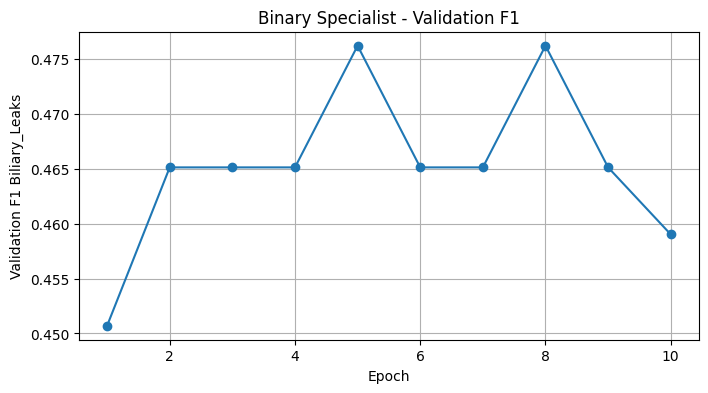

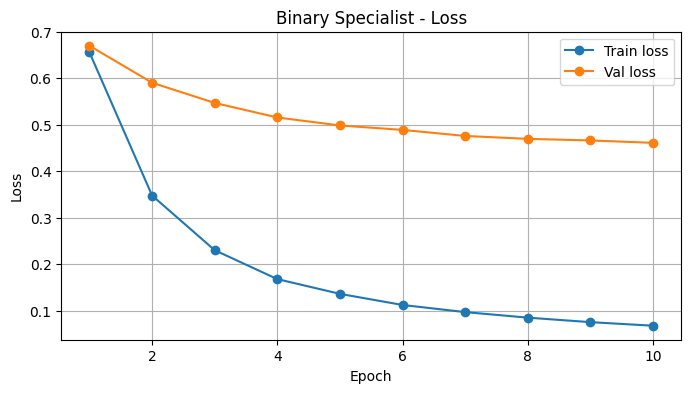

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(binary_history_df["epoch"], binary_history_df["val_f1_biliary"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation F1 Biliary_Leaks")
plt.title("Binary Specialist - Validation F1")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(binary_history_df["epoch"], binary_history_df["train_loss"], marker="o", label="Train loss")
plt.plot(binary_history_df["epoch"], binary_history_df["val_loss"], marker="o", label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Binary Specialist - Loss")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
binary_model.load_state_dict(torch.load(
    BINARY_BEST_MODEL_PATH,
    map_location=device
))

binary_y_val, binary_val_probs = predict_binary_probs(
    binary_model,
    binary_val_loader
)

binary_y_test, binary_test_probs = predict_binary_probs(
    binary_model,
    binary_test_loader
)

print("Best binary epoch:", best_binary_epoch)
print("Best validation threshold:", best_binary_threshold)

specialist_val_eval = evaluate_binary_probs(
    probs=binary_val_probs,
    y_true=binary_y_val,
    threshold=best_binary_threshold,
    title="Biliary_Leaks Specialist - Validation"
)

specialist_test_eval = evaluate_binary_probs(
    probs=binary_test_probs,
    y_true=binary_y_test,
    threshold=best_binary_threshold,
    title="Biliary_Leaks Specialist - Test"
)

Best binary epoch: 5
Best validation threshold: 0.74
================ Biliary_Leaks Specialist - Validation ================
Accuracy: 0.9060
Precision Biliary_Leaks: 0.5556
Recall Biliary_Leaks: 0.4167
F1 Biliary_Leaks: 0.4762
               precision    recall  f1-score   support

         Rest     0.9352    0.9619    0.9484       210
Biliary_Leaks     0.5556    0.4167    0.4762        24

     accuracy                         0.9060       234
    macro avg     0.7454    0.6893    0.7123       234
 weighted avg     0.8962    0.9060    0.8999       234

Confusion matrix [Rest, Biliary_Leaks]:
[[202   8]
 [ 14  10]]
================ Biliary_Leaks Specialist - Test ================
Accuracy: 0.9551
Precision Biliary_Leaks: 0.6471
Recall Biliary_Leaks: 0.6471
F1 Biliary_Leaks: 0.6471
               precision    recall  f1-score   support

         Rest     0.9760    0.9760    0.9760       250
Biliary_Leaks     0.6471    0.6471    0.6471        17

     accuracy                         0.

In [15]:
specialist_comparison = pd.DataFrame([
    {
        "Model": "EfficientNet-B7 multi-class baseline as Biliary detector",
        "Val F1 Biliary": baseline_binary_val_eval["f1_biliary"],
        "Val Precision Biliary": baseline_binary_val_eval["precision_biliary"],
        "Val Recall Biliary": baseline_binary_val_eval["recall_biliary"],
        "Test F1 Biliary": baseline_binary_test_eval["f1_biliary"],
        "Test Precision Biliary": baseline_binary_test_eval["precision_biliary"],
        "Test Recall Biliary": baseline_binary_test_eval["recall_biliary"],
        "Threshold": "argmax multi-class"
    },
    {
        "Model": "Biliary_Leaks binary specialist",
        "Val F1 Biliary": specialist_val_eval["f1_biliary"],
        "Val Precision Biliary": specialist_val_eval["precision_biliary"],
        "Val Recall Biliary": specialist_val_eval["recall_biliary"],
        "Test F1 Biliary": specialist_test_eval["f1_biliary"],
        "Test Precision Biliary": specialist_test_eval["precision_biliary"],
        "Test Recall Biliary": specialist_test_eval["recall_biliary"],
        "Threshold": best_binary_threshold
    }
])

specialist_comparison.round(4)

,Model,Val F1 Biliary,Val Precision Biliary,Val Recall Biliary,Test F1 Biliary,Test Precision Biliary,Test Recall Biliary,Threshold
0,EfficientNet-B7 multi-class baseline as Biliar...,0.3500,0.4375,0.2917,0.6250,0.6667,0.5882,argmax multi-class
1,Biliary_Leaks binary specialist,0.4762,0.5556,0.4167,0.6471,0.6471,0.6471,0.74


In [16]:
binary_history_df.to_csv(
    "/kaggle/working/biliary_specialist_vae_history.csv",
    index=False
)

specialist_comparison.to_csv(
    "/kaggle/working/biliary_specialist_vae_comparison.csv",
    index=False
)

print("Saved:")
print("/kaggle/working/efficientnet_b7_biliary_specialist_vae_best.pth")
print("/kaggle/working/biliary_specialist_vae_history.csv")
print("/kaggle/working/biliary_specialist_vae_comparison.csv")

Saved:
/kaggle/working/efficientnet_b7_biliary_specialist_vae_best.pth
/kaggle/working/biliary_specialist_vae_history.csv
/kaggle/working/biliary_specialist_vae_comparison.csv


# Testar no Ensemble Conservador

In [17]:
from torchvision.models import mobilenet_v2
from monai.networks.nets import DenseNet121 as MonaiDenseNet121

In [18]:
CHECKPOINTS = {
    "efficientnet": Path("/kaggle/input/models/martimflix/efficientnet/pytorch/default/1/efficientnet_b7.pth"),
    "densenet": Path("/kaggle/input/models/martimflix/densenet/pytorch/default/2/densenet.pth"),
    "mobilenet": Path("/kaggle/input/models/martimflix/mobilenet/pytorch/default/1/mobilenet_v2.pth"),
}

for name, path in CHECKPOINTS.items():
    print(name, path, path.exists())

efficientnet /kaggle/input/models/martimflix/efficientnet/pytorch/default/1/efficientnet_b7.pth True
densenet /kaggle/input/models/martimflix/densenet/pytorch/default/2/densenet.pth True
mobilenet /kaggle/input/models/martimflix/mobilenet/pytorch/default/1/mobilenet_v2.pth True


In [19]:
def create_ensemble_model(arch):
    if arch == "efficientnet":
        model = efficientnet_b7(weights=None)

        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            NUM_CLASSES
        )

    elif arch == "densenet":
        model = MonaiDenseNet121(
            spatial_dims=2,
            in_channels=3,
            out_channels=NUM_CLASSES
        )

    elif arch == "mobilenet":
        model = mobilenet_v2(weights=None)

        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            NUM_CLASSES
        )

    else:
        raise ValueError(f"Unknown architecture: {arch}")

    model = load_checkpoint_safely(
        model,
        CHECKPOINTS[arch]
    )

    model = model.to(device)
    model.eval()

    return model

In [20]:
@torch.no_grad()
def predict_multiclass_probs(model, loader):
    model.eval()

    all_probs = []

    for images, _ in loader:
        images = images.to(device)

        logits = model(images)
        probs = torch.softmax(logits, dim=1)

        all_probs.append(probs.detach().cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)

    return all_probs

In [21]:
ENSEMBLE_WEIGHTS = {
    "efficientnet": 0.70,
    "densenet": 0.27,
    "mobilenet": 0.03,
}

ensemble_val_probs = None
ensemble_test_probs = None

loaded_models = {}

for arch, weight in ENSEMBLE_WEIGHTS.items():
    print(f"Loading {arch}...")

    model_tmp = create_ensemble_model(arch)
    loaded_models[arch] = model_tmp

    val_probs_tmp = predict_multiclass_probs(
        model_tmp,
        binary_val_loader
    )

    test_probs_tmp = predict_multiclass_probs(
        model_tmp,
        binary_test_loader
    )

    if ensemble_val_probs is None:
        ensemble_val_probs = weight * val_probs_tmp
        ensemble_test_probs = weight * test_probs_tmp
    else:
        ensemble_val_probs += weight * val_probs_tmp
        ensemble_test_probs += weight * test_probs_tmp

    del model_tmp

    if device.type == "cuda":
        torch.cuda.empty_cache()

print("Ensemble probabilities ready.")

Loading efficientnet...
Checkpoint loaded.
Missing keys: 0
Unexpected keys: 0
Loading densenet...
Checkpoint loaded.
Missing keys: 0
Unexpected keys: 0
Loading mobilenet...
Checkpoint loaded.
Missing keys: 0
Unexpected keys: 0
Ensemble probabilities ready.


In [22]:
def get_multiclass_true_labels_from_files(image_files):
    labels = []

    for path in image_files:
        cls = Path(path).parent.name
        labels.append(CLASS_NAMES.index(cls))

    return np.array(labels)


y_val_multiclass = get_multiclass_true_labels_from_files(binary_val_files)
y_test_multiclass = get_multiclass_true_labels_from_files(binary_test_files)

print("Val labels:", y_val_multiclass.shape)
print("Test labels:", y_test_multiclass.shape)

Val labels: (234,)
Test labels: (267,)


In [23]:
def evaluate_multiclass_predictions(y_true, y_pred, title):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"================ {title} ================")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")

    print(classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    ))

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES))
    )

    print("Confusion matrix:")
    print(cm)

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "y_pred": y_pred,
        "cm": cm
    }


ensemble_val_preds = np.argmax(ensemble_val_probs, axis=1)
ensemble_test_preds = np.argmax(ensemble_test_probs, axis=1)

ensemble_val_eval = evaluate_multiclass_predictions(
    y_val_multiclass,
    ensemble_val_preds,
    title="Conservative Ensemble - Validation"
)

ensemble_test_eval = evaluate_multiclass_predictions(
    y_test_multiclass,
    ensemble_test_preds,
    title="Conservative Ensemble - Test"
)

================ Conservative Ensemble - Validation ================
Accuracy: 0.6966
Macro-F1: 0.6339
               precision    recall  f1-score   support

Biliary_Leaks     0.6154    0.3333    0.4324        24
    Lithiasis     0.8556    0.7857    0.8191        98
       Normal     0.5942    0.6949    0.6406        59
    Stricture     0.5968    0.6981    0.6435        53

     accuracy                         0.6966       234
    macro avg     0.6655    0.6280    0.6339       234
 weighted avg     0.7064    0.6966    0.6947       234

Confusion matrix:
[[ 8  1 11  4]
 [ 2 77  7 12]
 [ 3  6 41  9]
 [ 0  6 10 37]]
================ Conservative Ensemble - Test ================
Accuracy: 0.7865
Macro-F1: 0.7465
               precision    recall  f1-score   support

Biliary_Leaks     0.6667    0.5882    0.6250        17
    Lithiasis     0.8532    0.7561    0.8017       123
       Normal     0.5821    0.9070    0.7091        43
    Stricture     0.8947    0.8095    0.8500        84

 

In [24]:
SPECIALIST_MODEL_PATH = "/kaggle/working/efficientnet_b7_biliary_specialist_vae_best.pth"

binary_model.load_state_dict(torch.load(
    SPECIALIST_MODEL_PATH,
    map_location=device
))

binary_y_val, binary_val_probs = predict_binary_probs(
    binary_model,
    binary_val_loader
)

binary_y_test, binary_test_probs = predict_binary_probs(
    binary_model,
    binary_test_loader
)

SPECIALIST_THRESHOLD = 0.74

print("Specialist threshold:", SPECIALIST_THRESHOLD)
print("Validation specialist positives:", int((binary_val_probs >= SPECIALIST_THRESHOLD).sum()))
print("Test specialist positives:", int((binary_test_probs >= SPECIALIST_THRESHOLD).sum()))

Specialist threshold: 0.74
Validation specialist positives: 18
Test specialist positives: 17


In [25]:
ensemble_val_preds_hybrid = ensemble_val_preds.copy()
ensemble_test_preds_hybrid = ensemble_test_preds.copy()

val_specialist_positive = binary_val_probs >= SPECIALIST_THRESHOLD
test_specialist_positive = binary_test_probs >= SPECIALIST_THRESHOLD

ensemble_val_preds_hybrid[val_specialist_positive] = POSITIVE_IDX
ensemble_test_preds_hybrid[test_specialist_positive] = POSITIVE_IDX

hybrid_ensemble_val_eval = evaluate_multiclass_predictions(
    y_val_multiclass,
    ensemble_val_preds_hybrid,
    title="Conservative Ensemble + Biliary Specialist Override - Validation"
)

hybrid_ensemble_test_eval = evaluate_multiclass_predictions(
    y_test_multiclass,
    ensemble_test_preds_hybrid,
    title="Conservative Ensemble + Biliary Specialist Override - Test"
)

================ Conservative Ensemble + Biliary Specialist Override - Validation ================
Accuracy: 0.7009
Macro-F1: 0.6546
               precision    recall  f1-score   support

Biliary_Leaks     0.5789    0.4583    0.5116        24
    Lithiasis     0.8539    0.7755    0.8128        98
       Normal     0.6250    0.6780    0.6504        59
    Stricture     0.5968    0.6981    0.6435        53

     accuracy                         0.7009       234
    macro avg     0.6637    0.6525    0.6546       234
 weighted avg     0.7098    0.7009    0.7026       234

Confusion matrix:
[[11  1  8  4]
 [ 3 76  7 12]
 [ 4  6 40  9]
 [ 1  6  9 37]]
================ Conservative Ensemble + Biliary Specialist Override - Test ================
Accuracy: 0.7865
Macro-F1: 0.7499
               precision    recall  f1-score   support

Biliary_Leaks     0.6471    0.6471    0.6471        17
    Lithiasis     0.8611    0.7561    0.8052       123
       Normal     0.5758    0.8837    0.6972        

In [26]:
hybrid_ensemble_comparison = pd.DataFrame([
    {
        "Model": "EfficientNet-B7 baseline",
        "Val Macro-F1": 0.6008,
        "Test Macro-F1": 0.7439
    },
    {
        "Model": "Conservative ensemble",
        "Val Macro-F1": ensemble_val_eval["macro_f1"],
        "Test Macro-F1": ensemble_test_eval["macro_f1"]
    },
    {
        "Model": "Conservative ensemble + Biliary specialist override",
        "Val Macro-F1": hybrid_ensemble_val_eval["macro_f1"],
        "Test Macro-F1": hybrid_ensemble_test_eval["macro_f1"]
    }
])

hybrid_ensemble_comparison.round(4)

,Model,Val Macro-F1,Test Macro-F1
0,EfficientNet-B7 baseline,0.6008,0.7439
1,Conservative ensemble,0.6339,0.7465
2,Conservative ensemble + Biliary specialist ove...,0.6546,0.7499


In [27]:
def extract_class_metrics(y_true, y_pred, class_idx):
    report = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
        output_dict=True
    )

    class_name = CLASS_NAMES[class_idx]

    return {
        "Precision": report[class_name]["precision"],
        "Recall": report[class_name]["recall"],
        "F1": report[class_name]["f1-score"]
    }


ensemble_val_biliary = extract_class_metrics(
    y_val_multiclass,
    ensemble_val_preds,
    POSITIVE_IDX
)

ensemble_test_biliary = extract_class_metrics(
    y_test_multiclass,
    ensemble_test_preds,
    POSITIVE_IDX
)

hybrid_val_biliary = extract_class_metrics(
    y_val_multiclass,
    ensemble_val_preds_hybrid,
    POSITIVE_IDX
)

hybrid_test_biliary = extract_class_metrics(
    y_test_multiclass,
    ensemble_test_preds_hybrid,
    POSITIVE_IDX
)


biliary_override_comparison = pd.DataFrame([
    {
        "Model": "Conservative ensemble",
        "Val Precision Biliary": ensemble_val_biliary["Precision"],
        "Val Recall Biliary": ensemble_val_biliary["Recall"],
        "Val F1 Biliary": ensemble_val_biliary["F1"],
        "Test Precision Biliary": ensemble_test_biliary["Precision"],
        "Test Recall Biliary": ensemble_test_biliary["Recall"],
        "Test F1 Biliary": ensemble_test_biliary["F1"],
    },
    {
        "Model": "Conservative ensemble + specialist override",
        "Val Precision Biliary": hybrid_val_biliary["Precision"],
        "Val Recall Biliary": hybrid_val_biliary["Recall"],
        "Val F1 Biliary": hybrid_val_biliary["F1"],
        "Test Precision Biliary": hybrid_test_biliary["Precision"],
        "Test Recall Biliary": hybrid_test_biliary["Recall"],
        "Test F1 Biliary": hybrid_test_biliary["F1"],
    }
])

biliary_override_comparison.round(4)

,Model,Val Precision Biliary,Val Recall Biliary,Val F1 Biliary,Test Precision Biliary,Test Recall Biliary,Test F1 Biliary
0,Conservative ensemble,0.6154,0.3333,0.4324,0.6667,0.5882,0.6250
1,Conservative ensemble + specialist override,0.5789,0.4583,0.5116,0.6471,0.6471,0.6471


In [28]:
final_results = pd.DataFrame([
    {
        "Model": "EfficientNet-B7 baseline",
        "Val Macro-F1": 0.6008,
        "Test Macro-F1": 0.7439,
        "Notes": "Original baseline checkpoint"
    },
    {
        "Model": "Conservative ensemble",
        "Val Macro-F1": ensemble_val_eval["macro_f1"],
        "Test Macro-F1": ensemble_test_eval["macro_f1"],
        "Notes": "EfficientNet 0.70 + DenseNet 0.27 + MobileNet 0.03"
    },
    {
        "Model": "Conservative ensemble + Biliary specialist override",
        "Val Macro-F1": hybrid_ensemble_val_eval["macro_f1"],
        "Test Macro-F1": hybrid_ensemble_test_eval["macro_f1"],
        "Notes": "Final selected system; specialist threshold = 0.74"
    }
])

final_results.round(4)

,Model,Val Macro-F1,Test Macro-F1,Notes
0,EfficientNet-B7 baseline,0.6008,0.7439,Original baseline checkpoint
1,Conservative ensemble,0.6339,0.7465,EfficientNet 0.70 + DenseNet 0.27 + MobileNet ...
2,Conservative ensemble + Biliary specialist ove...,0.6546,0.7499,Final selected system; specialist threshold = ...


In [29]:
final_results.to_csv(
    "/kaggle/working/final_model_comparison.csv",
    index=False
)

biliary_override_comparison.to_csv(
    "/kaggle/working/final_biliary_override_comparison.csv",
    index=False
)

print("Saved:")
print("/kaggle/working/final_model_comparison.csv")
print("/kaggle/working/final_biliary_override_comparison.csv")

Saved:
/kaggle/working/final_model_comparison.csv
/kaggle/working/final_biliary_override_comparison.csv
